In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from factor_analyzer import FactorAnalyzer
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree

In [3]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [4]:
df_original = df.copy()

In [5]:
# 1) JobLevel별 평균 YearsInCurrentRole 계산
joblevel_mean = df_original.groupby("JobLevel")["YearsInCurrentRole"].mean()
print(joblevel_mean)
#이런 series

JobLevel
1    2.513812
2    4.456929
3    6.114679
4    6.537736
5    6.463768
Name: YearsInCurrentRole, dtype: float64


In [ ]:
# 1) JobLevel별 평균 YearsInCurrentRole 계산
joblevel_mean = df_original.groupby("JobLevel")["YearsInCurrentRole"].mean()
# 2) 각 직원에게 평균값 매핑
df_original["MeanYearsByJobLevel"] = df_original["JobLevel"].map(joblevel_mean)
# 3) GrowthPotential2 계산
df_original["GrowthPotential2"] = df_original["MeanYearsByJobLevel"] - df_original["YearsInCurrentRole"]

In [6]:
# 2) 각 직원에게 평균값 매핑
df_original["MeanYearsByJobLevel"] = df_original["JobLevel"].map(joblevel_mean)
#각 직원의 joblevel에 맞는 평균값을 mapping하여, 해당 직원의 joblevel의 yearincurrentrole의 평균값 열도 넣음

In [7]:
# 3) GrowthPotential2 계산
df_original["GrowthPotential2"] = df_original["MeanYearsByJobLevel"] - df_original["YearsInCurrentRole"]
df_original

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,MeanYearsByJobLevel,GrowthPotential2
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,0,8,0,1,6,4,0,5,4.456929,0.456929
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,1,10,3,3,10,7,1,7,4.456929,-2.543071
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,0,7,3,3,0,0,0,0,2.513812,2.513812
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,0,8,3,3,8,7,3,0,2.513812,-4.486188
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,1,6,3,3,2,2,2,2,2.513812,0.513812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,1,17,3,3,5,2,0,3,4.456929,2.456929
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,9,5,3,7,7,1,7,6.114679,-0.885321
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,1,6,0,3,6,2,0,3,4.456929,2.456929
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,0,17,3,2,9,6,0,8,4.456929,-1.543071


In [8]:

# 각 변수별 고유값 출력
for col in df.columns:
    print(f"----- {col} -----")
    print(df[col].unique())
    print("\n")
    
selected_cols = [
    "MonthlyIncome",
    "YearsAtCompany",
    "Age",
    "JobSatisfaction", 
    "WorkLifeBalance",
    "OverTime",
    "RelationshipSatisfaction",
    "DistanceFromHome",
    "PercentSalaryHike",
    "GrowthPotential2",
    "Attrition"   # 종속변수 꼭 포함해야 함!
]
df = df_original[selected_cols]

----- Age -----
[41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60]


----- Attrition -----
['Yes' 'No']


----- BusinessTravel -----
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']


----- DailyRate -----
[1102  279 1373 1392  591 1005 1324 1358  216 1299  809  153  670 1346
  103 1389  334 1123 1219  371  673 1218  419  391  699 1282 1125  691
  477  705  924 1459  125  895  813 1273  869  890  852 1141  464 1240
 1357  994  721 1360 1065  408 1211 1229  626 1434 1488 1097 1443  515
  853 1142  655 1115  427  653  989 1435 1223  836 1195 1339  664  318
 1225 1328 1082  548  132  746  776  193  397  945 1214  111  573 1153
 1400  541  432  288  669  530  632 1334  638 1093 1217 1353  120  682
  489  807  827  871  665 1040 1420  240 1280  534 1456  658  142 1127
 1031 1189 1354 1467  922  394 1312  750  441  684  249  841  147  528
  594  470  957  542  802 1355 1150 1329  959 1033 1316  364  438  689
 

In [9]:
df.columns

Index(['MonthlyIncome', 'YearsAtCompany', 'Age', 'JobSatisfaction',
       'WorkLifeBalance', 'OverTime', 'RelationshipSatisfaction',
       'DistanceFromHome', 'PercentSalaryHike', 'GrowthPotential2',
       'Attrition'],
      dtype='object')

In [10]:
df

,MonthlyIncome,YearsAtCompany,Age,JobSatisfaction,WorkLifeBalance,OverTime,RelationshipSatisfaction,DistanceFromHome,PercentSalaryHike,GrowthPotential2,Attrition
0,5993,6,41,4,1,Yes,1,1,11,0.456929,Yes
1,5130,10,49,2,3,No,4,8,23,-2.543071,No
2,2090,0,37,3,3,Yes,2,2,15,2.513812,Yes
3,2909,8,33,3,3,Yes,3,3,11,-4.486188,No
4,3468,2,27,2,3,No,4,2,12,0.513812,No
...,...,...,...,...,...,...,...,...,...,...,...
1465,2571,5,36,4,3,No,3,23,17,2.456929,No
1466,9991,7,39,1,3,No,1,6,15,-0.885321,No
1467,6142,6,27,2,3,Yes,2,4,20,2.456929,No
1468,5390,9,49,2,2,No,4,2,14,-1.543071,No


In [11]:
#결측치 확인
print(df.isnull().sum())

MonthlyIncome               0
YearsAtCompany              0
Age                         0
JobSatisfaction             0
WorkLifeBalance             0
OverTime                    0
RelationshipSatisfaction    0
DistanceFromHome            0
PercentSalaryHike           0
GrowthPotential2            0
Attrition                   0
dtype: int64


In [12]:
#기초통계량 확인
print(df.describe())

       MonthlyIncome  YearsAtCompany          Age  JobSatisfaction  \
count    1470.000000     1470.000000  1470.000000      1470.000000   
mean     6502.931293        7.008163    36.923810         2.728571   
std      4707.956783        6.126525     9.135373         1.102846   
min      1009.000000        0.000000    18.000000         1.000000   
25%      2911.000000        3.000000    30.000000         2.000000   
50%      4919.000000        5.000000    36.000000         3.000000   
75%      8379.000000        9.000000    43.000000         4.000000   
max     19999.000000       40.000000    60.000000         4.000000   

       WorkLifeBalance  RelationshipSatisfaction  DistanceFromHome  \
count      1470.000000               1470.000000       1470.000000   
mean          2.761224                  2.712245          9.192517   
std           0.706476                  1.081209          8.106864   
min           1.000000                  1.000000          1.000000   
25%           2.000

In [13]:
# 범주형 변수 비율 확인, Attrition, OverTime 두 개가 범주형
print(df['Attrition'].value_counts(normalize=True))
print(df['OverTime'].value_counts(normalize=True))

No     0.838776
Yes    0.161224
Name: Attrition, dtype: float64
No     0.717007
Yes    0.282993
Name: OverTime, dtype: float64


In [14]:
# 범주형 인코딩
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})


C:\Users\Manager\AppData\Local\Temp\ipykernel_19040\859799433.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
C:\Users\Manager\AppData\Local\Temp\ipykernel_19040\859799433.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})


In [15]:
# ---- (1) 범주형 더미 처리 ----
df_vif = df.copy()


# Attrition(Yes/No)도 종속변수이므로 VIF에서는 제외
df_vif = df_vif.drop("Attrition", axis=1)

# ---- (2) VIF 계산을 위한 수치형 행렬 준비 ----
X = sm.add_constant(df_vif)  # 상수항 추가

vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df)
#const는 상수항(베타제로)
#변수들 간 다중공선성 없음!!!

                    Variable        VIF
0                      const  64.942020
1              MonthlyIncome   1.946720
2             YearsAtCompany   2.704755
3                        Age   1.347710
4            JobSatisfaction   1.001594
5            WorkLifeBalance   1.007517
6                   OverTime   1.006098
7   RelationshipSatisfaction   1.008532
8           DistanceFromHome   1.003992
9          PercentSalaryHike   1.007195
10          GrowthPotential2   1.981434


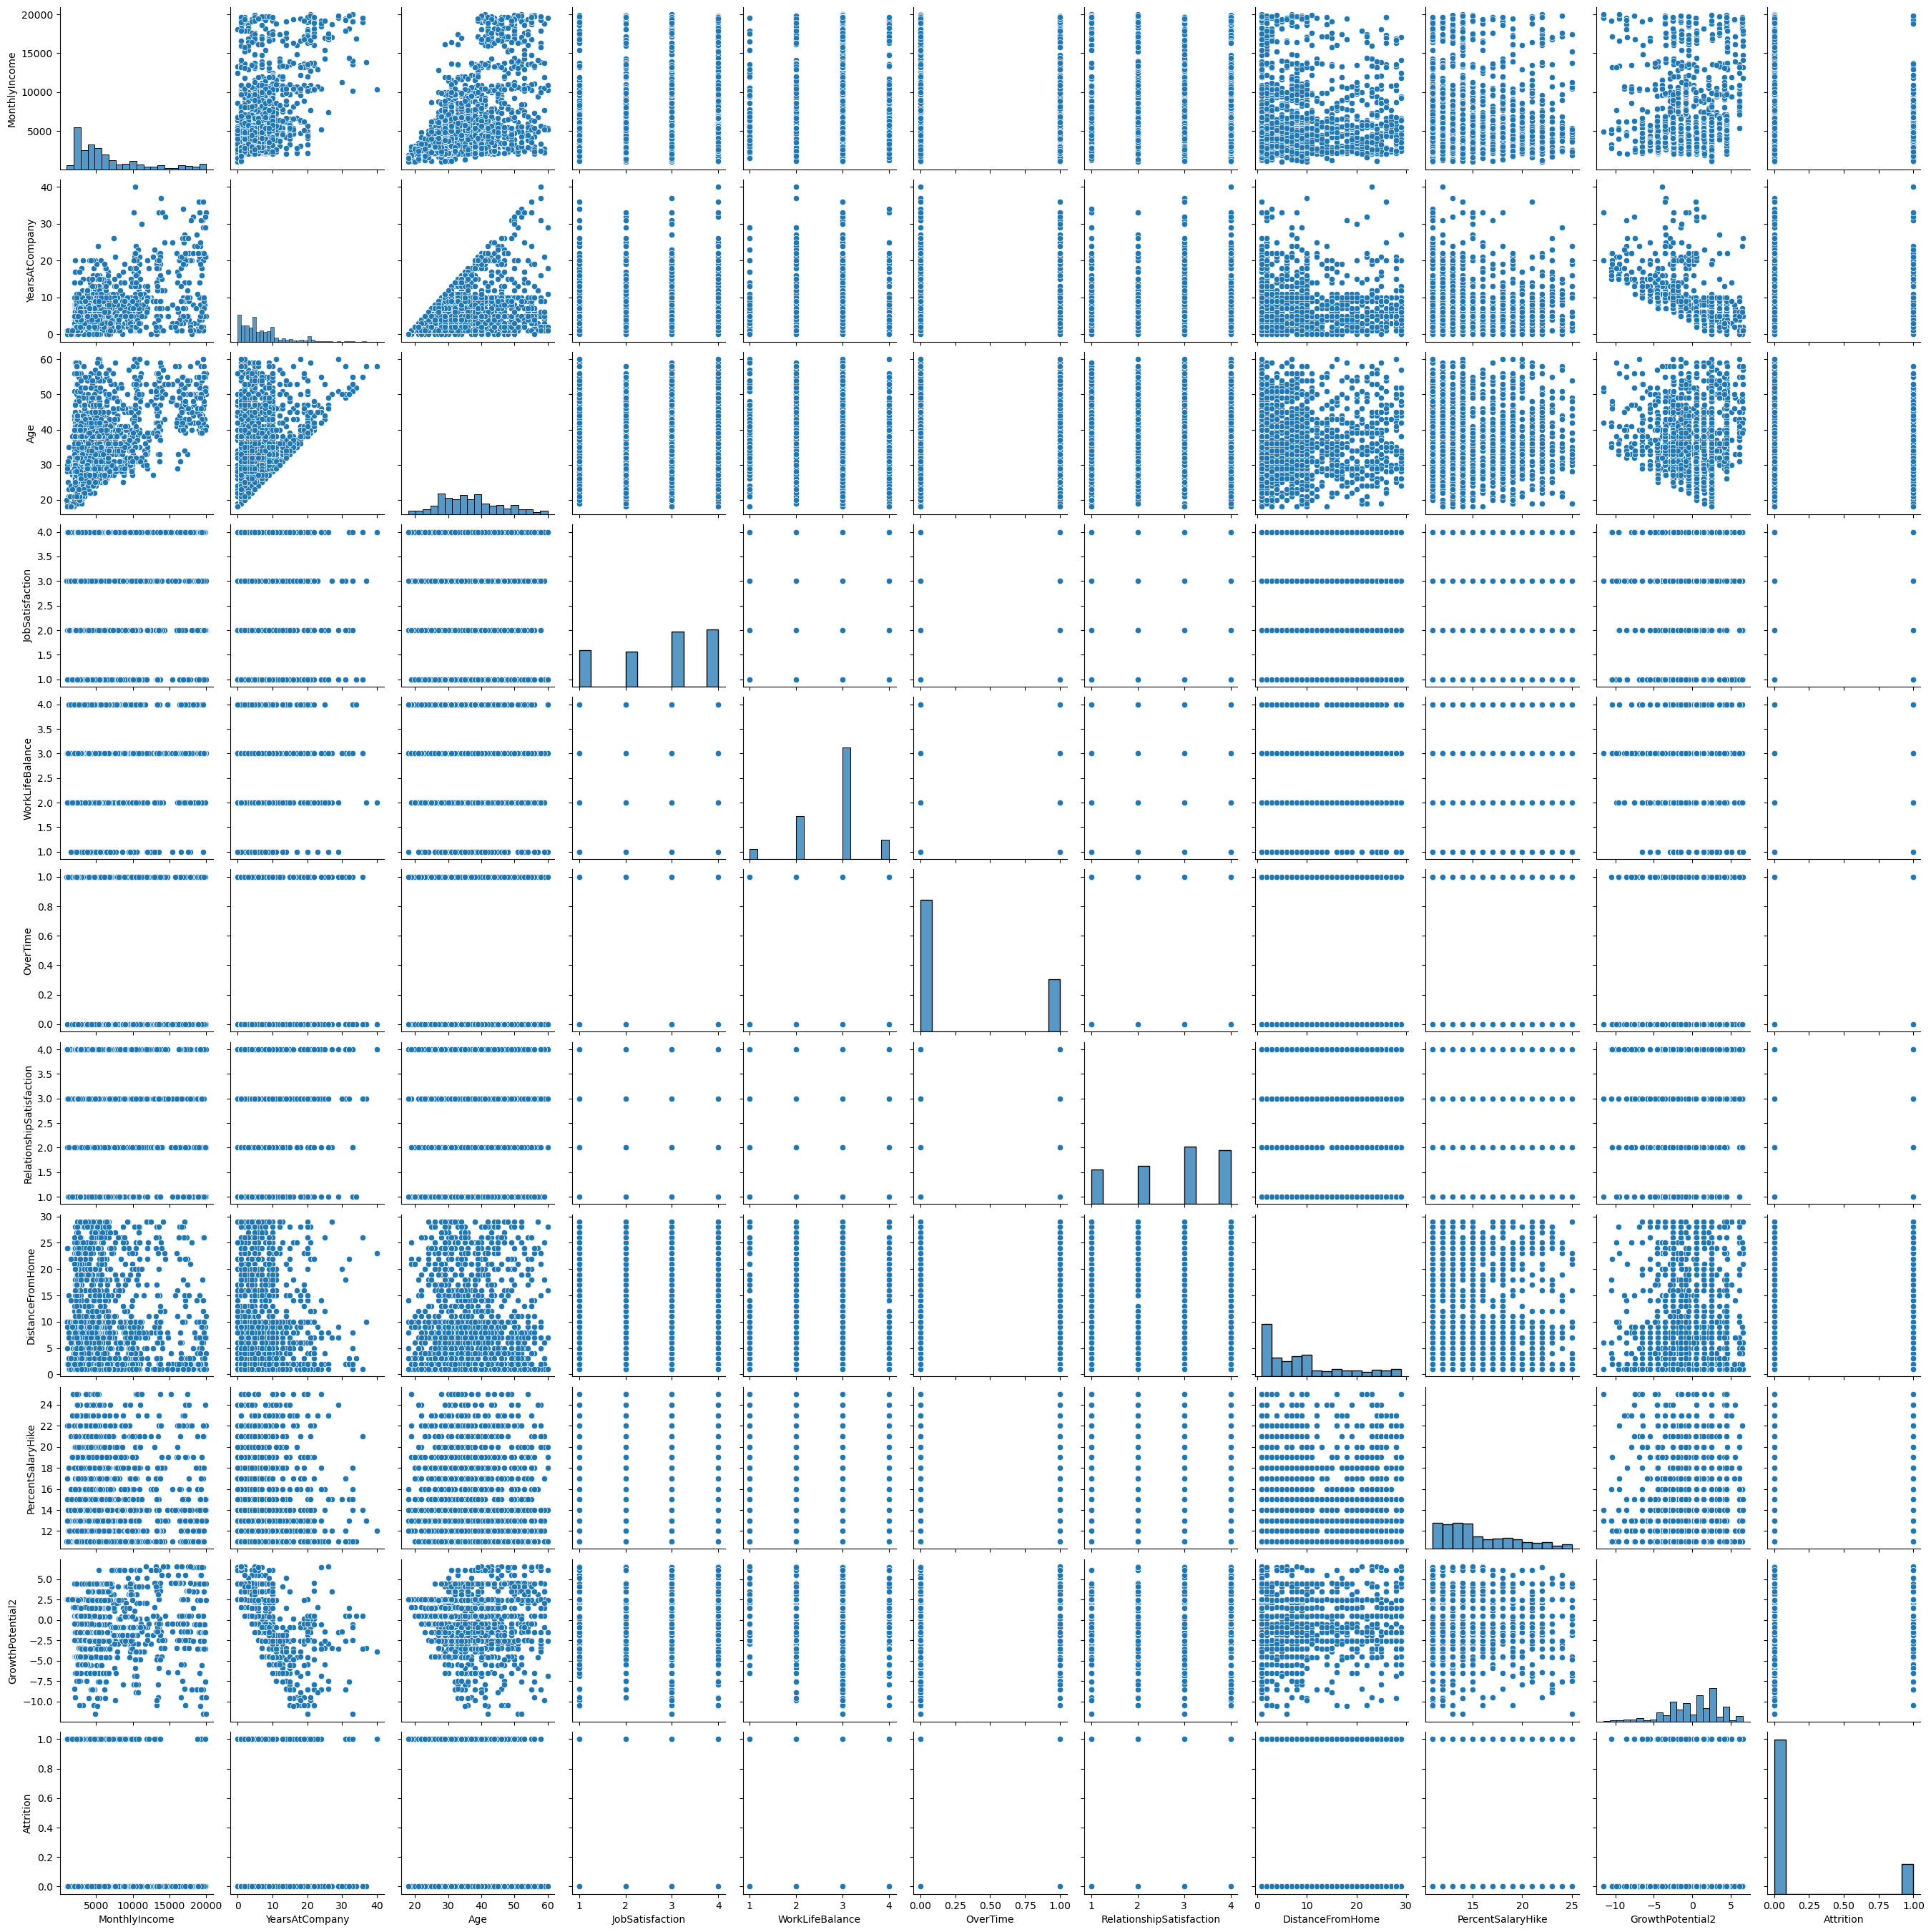

In [16]:
sns.pairplot(df)
plt.show()

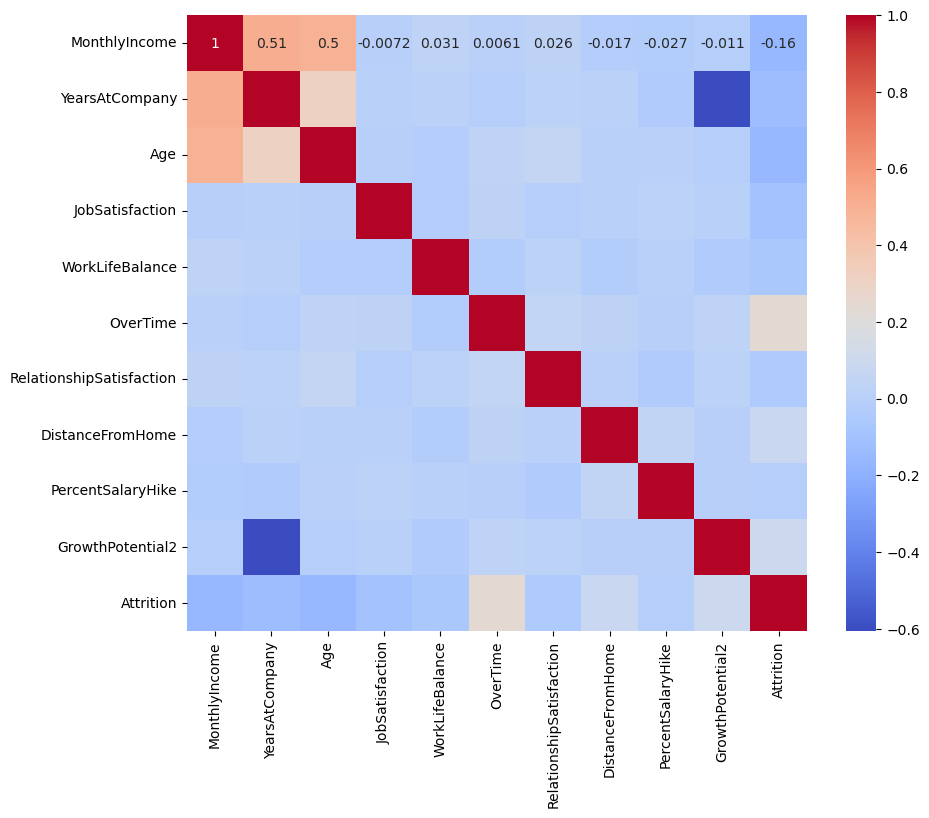

In [17]:
# 상관계수 계산
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

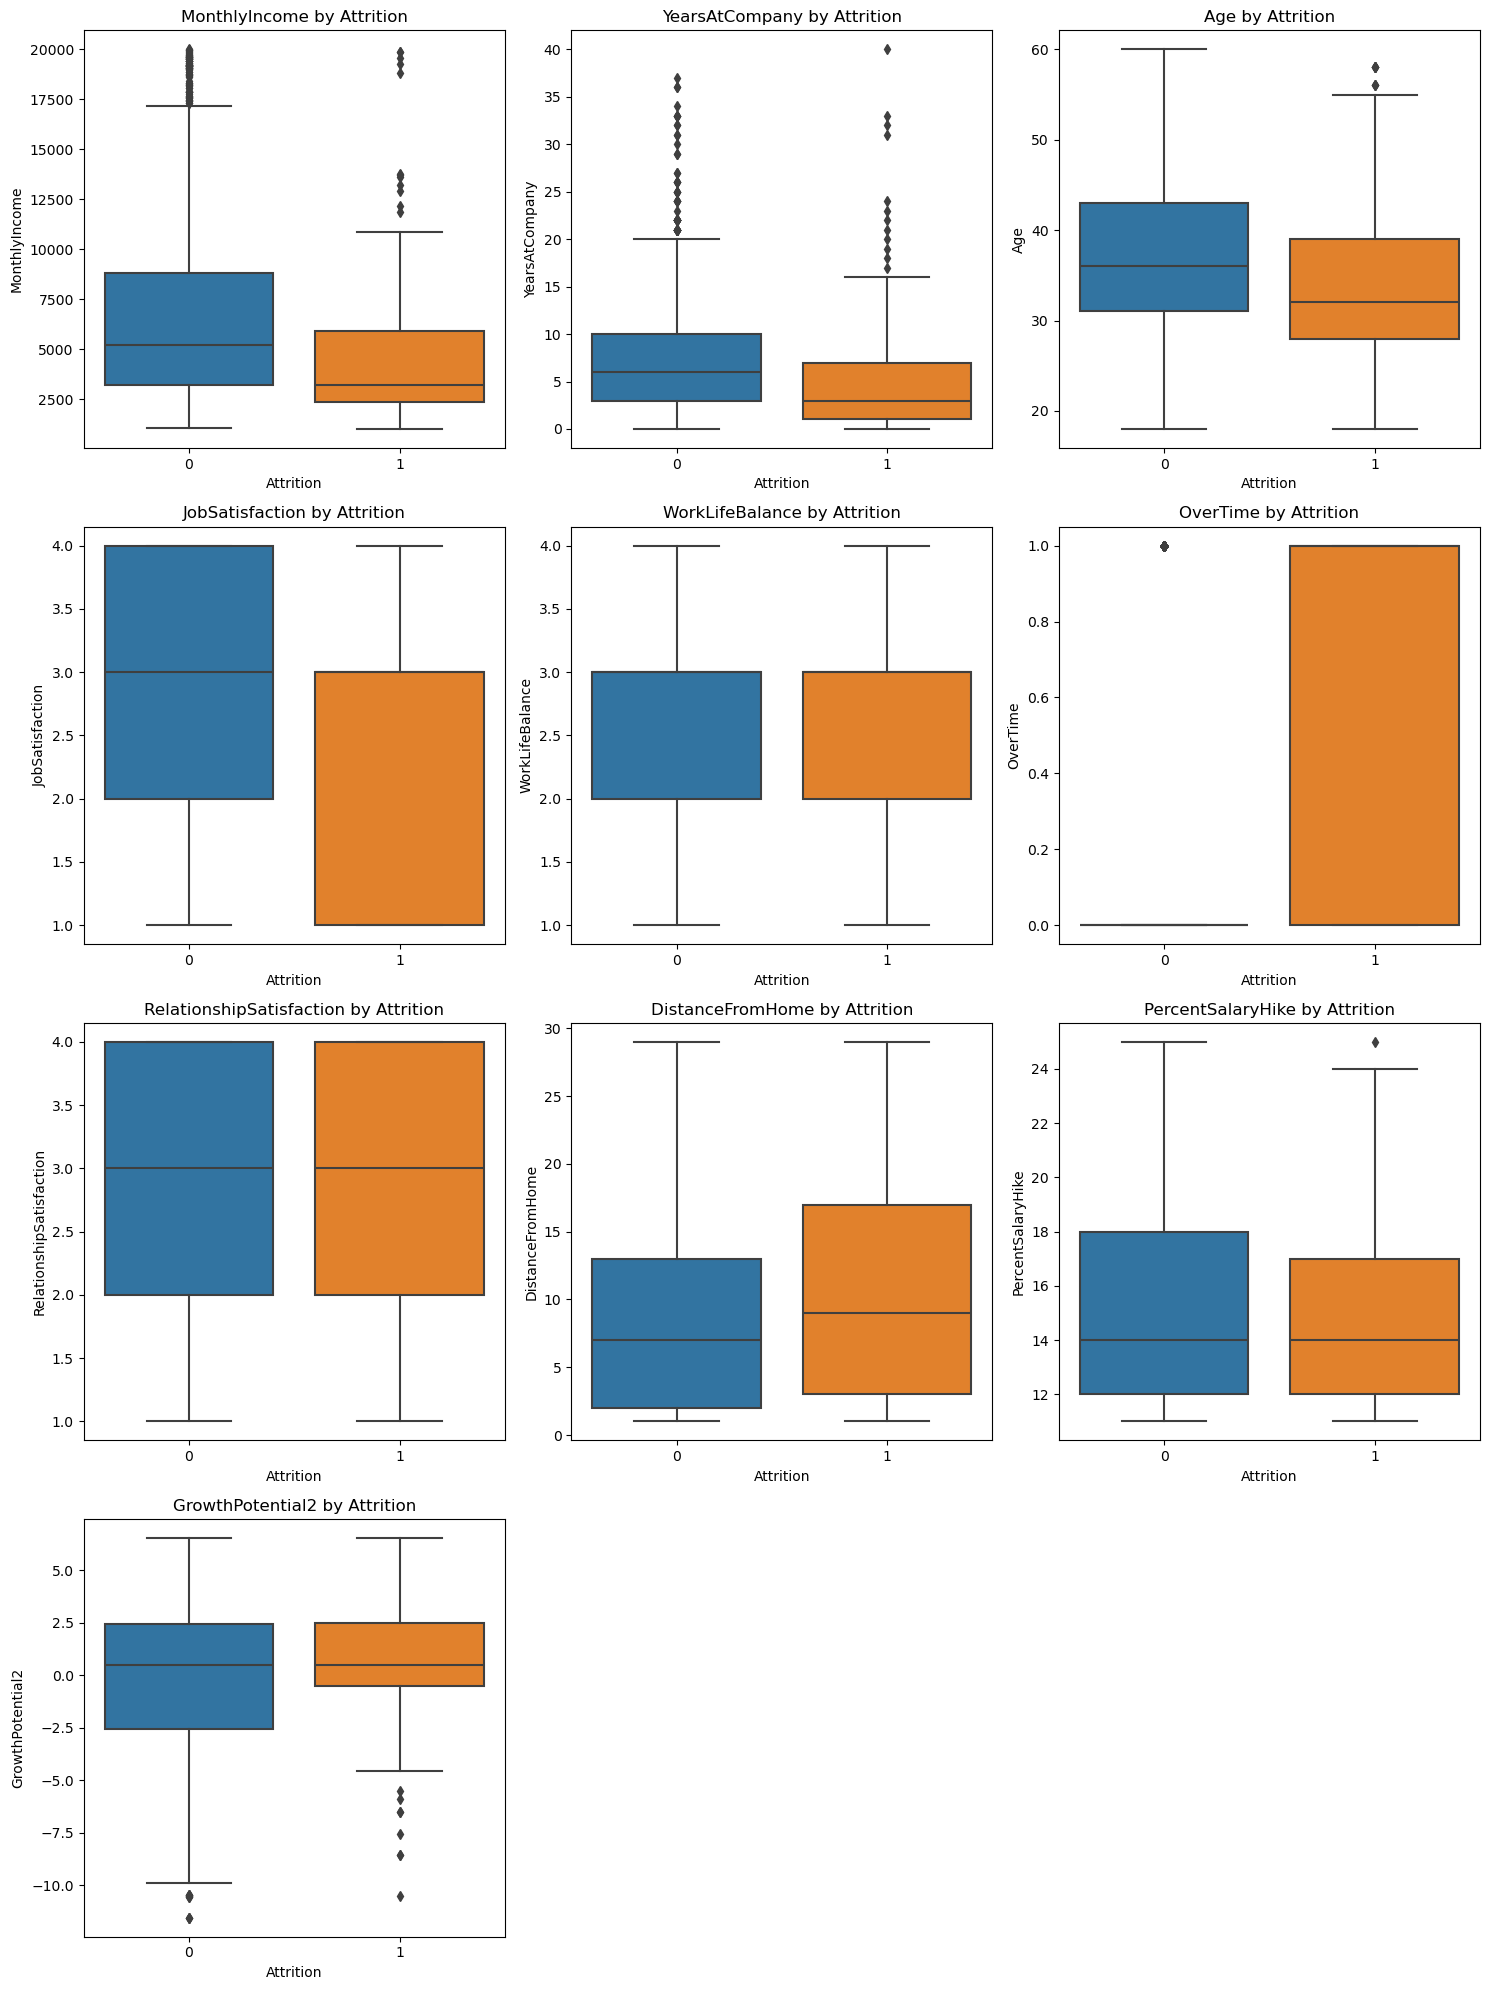

In [18]:
df_small = df[selected_cols]

# 종속변수
y = df_small["Attrition"]

# 독립변수들
X_cols = [c for c in df_small.columns if c != "Attrition"]
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 20)) 

for i, col in enumerate(X_cols, 1):
    plt.subplot(4, 3, i)  # 12개면 4x3 레이아웃
    sns.boxplot(data=df_small, x="Attrition", y=col)
    plt.title(f"{col} by Attrition")

plt.tight_layout()
plt.show()

In [19]:
#요인분석 코드
#숫자 변수만 선
fa_cols = [
    "MonthlyIncome",
    "YearsAtCompany",
    "Age",
    "JobSatisfaction",
    "WorkLifeBalance",
    "OverTime",
    "RelationshipSatisfaction",
    "DistanceFromHome",
    "PercentSalaryHike",
    "GrowthPotential2"
]

X = df[fa_cols].dropna()

In [20]:
# 1) 요인 수 없이 eigenvalue만 계산
fa = FactorAnalyzer(rotation=None)
fa.fit(X)

ev, v = fa.get_eigenvalues()


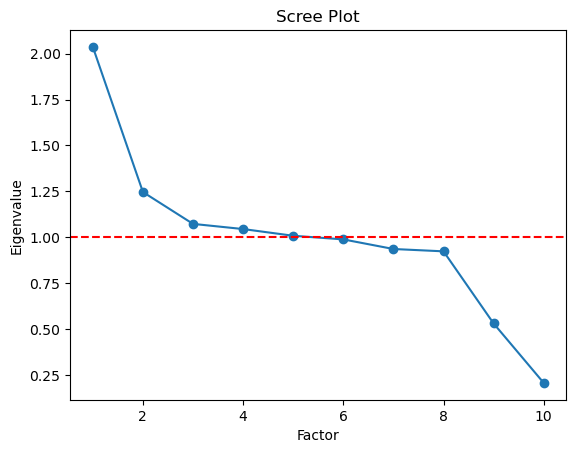

In [21]:
plt.plot(range(1, len(ev)+1), ev, marker='o')
plt.axhline(1, color='red', linestyle='--')
plt.title("Scree Plot")
plt.xlabel("Factor")
plt.ylabel("Eigenvalue")
plt.show()
#고유값을 요인 번호 순서대로 그린것
#고유값이 크다-> 해당 요인이 많은 분산을 설명한다=중요한 요인
#대부분 고유값>1인 요인만 유지, 빨간 점선이 기준
#고유값 1을 넘는 요인은 총 4개~5개

In [22]:
fa = FactorAnalyzer(n_factors=4, rotation='varimax')
fa.fit(X)
loadings = pd.DataFrame(fa.loadings_, index=X.columns)
loadings

,0,1,2,3
MonthlyIncome,0.922385,-0.033324,-0.006350,-0.128009
YearsAtCompany,0.530251,-0.629333,0.010271,-0.034886
Age,0.548039,-0.036183,0.059696,0.068906
JobSatisfaction,-0.001836,-0.000369,-0.013037,0.083397
WorkLifeBalance,-0.004487,-0.024050,0.012366,-0.195238
OverTime,0.025944,0.027677,0.079877,0.142750
RelationshipSatisfaction,0.026408,0.003638,0.691284,-0.047052
DistanceFromHome,-0.002333,-0.014231,0.016655,0.147253
PercentSalaryHike,-0.022168,-0.000013,-0.052100,0.097675
GrowthPotential2,0.028568,0.986015,0.027325,0.036266


In [24]:
#표준화
scaler = StandardScaler()
X_s = scaler.fit_transform(X)
X_s = pd.DataFrame(X_s, columns=X.columns)


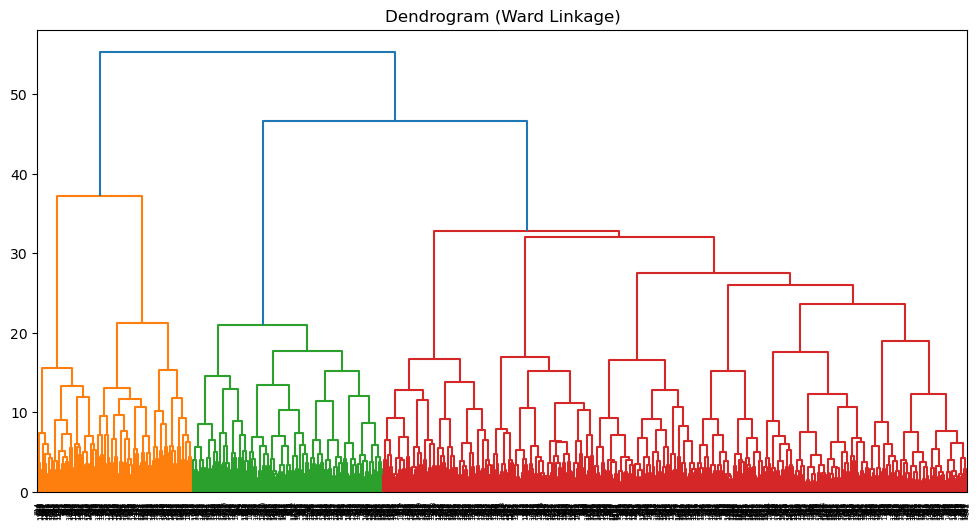

In [30]:
# Ward linkage
hc_ward = linkage(X_s, method="ward")

plt.figure(figsize=(12,6))
dendrogram(hc_ward)
plt.title("Dendrogram (Ward Linkage)")
plt.show()

In [31]:
from scipy.cluster.hierarchy import cut_tree
#군집 4개
k = 4
clusters_hc = cut_tree(hc_ward, n_clusters=k).flatten()

df["cluster_hc"] = pd.Categorical(clusters_hc)

C:\Users\Manager\AppData\Local\Temp\ipykernel_19040\891170640.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["cluster_hc"] = pd.Categorical(clusters_hc)


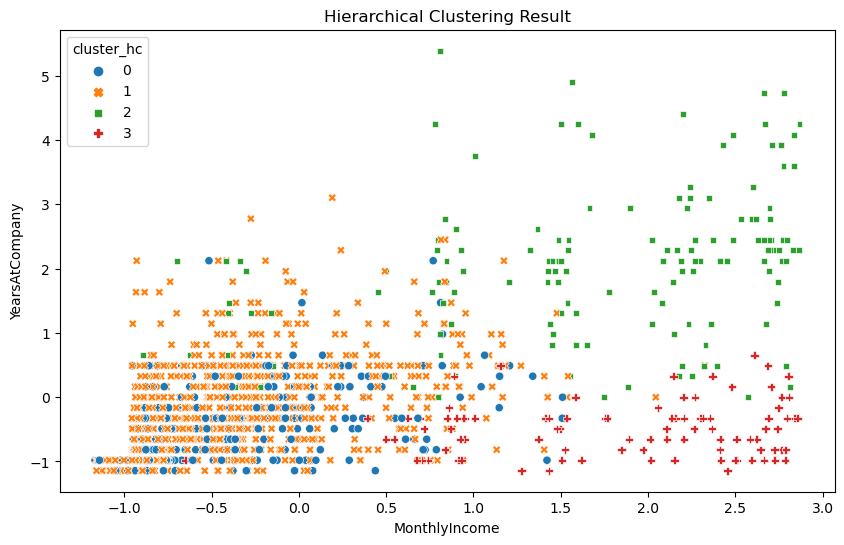

In [32]:
import seaborn as sns
#시각화
plt.figure(figsize=(10,6))
sns.scatterplot(x=X_s.iloc[:,0], y=X_s.iloc[:,1],
                hue=df["cluster_hc"], style=df["cluster_hc"])
plt.title("Hierarchical Clustering Result")
plt.show()


In [33]:
#군집별 평균 테이블
df.groupby("cluster_hc").mean()

,MonthlyIncome,YearsAtCompany,Age,JobSatisfaction,WorkLifeBalance,OverTime,RelationshipSatisfaction,DistanceFromHome,PercentSalaryHike,GrowthPotential2,Attrition
cluster_hc,,,,,,,,,,,
0,4811.096346,4.637874,34.807309,2.843854,2.687708,1.000000,2.720930,9.345515,15.289037,0.898919,0.365449
1,4889.930736,6.071429,35.161255,2.698052,2.760823,0.035714,2.700216,9.088745,15.022727,-0.231796,0.113636
2,14408.133333,19.486667,45.313333,2.673333,2.913333,0.333333,2.820000,10.273333,15.966667,-3.131800,0.126667
3,15070.031579,3.926316,47.526316,2.747368,2.757895,0.336842,2.631579,8.010526,15.578947,4.351313,0.031579


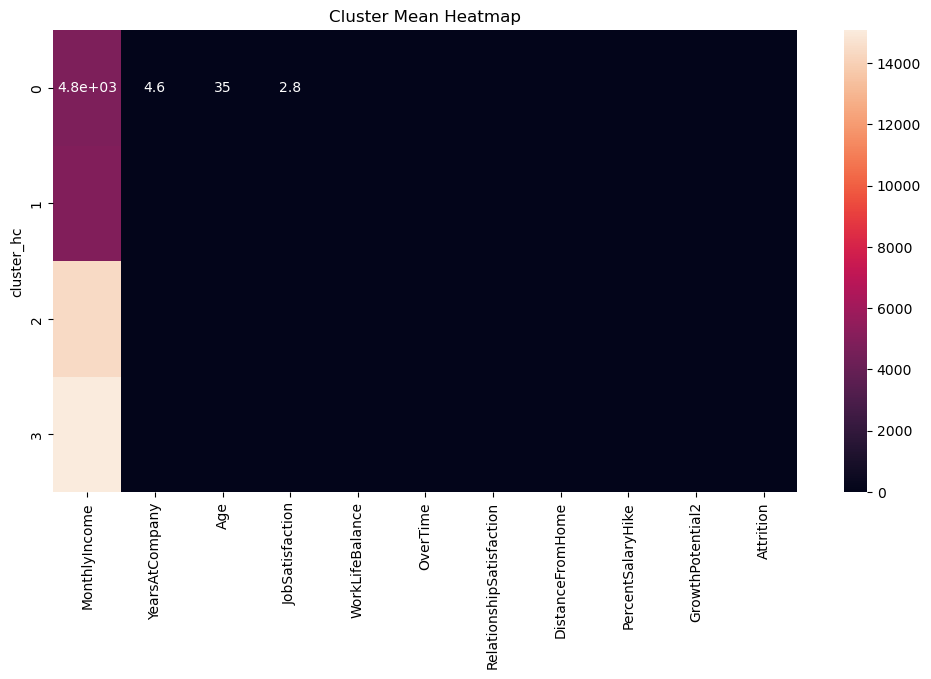

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_means = df.groupby("cluster_hc").mean()

plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, annot=True)
plt.title("Cluster Mean Heatmap")
plt.show()


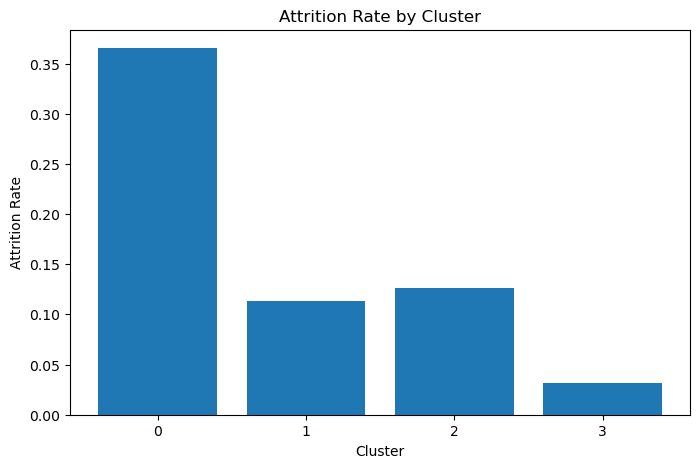

In [37]:
plt.figure(figsize=(8,5))
attrition_rates = df.groupby("cluster_hc")["Attrition"].mean()

plt.bar(attrition_rates.index.astype(str), attrition_rates.values)
plt.title("Attrition Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Attrition Rate")
plt.show()


### 0집단이 attrition 비율이 제일 높다.

### k-mean

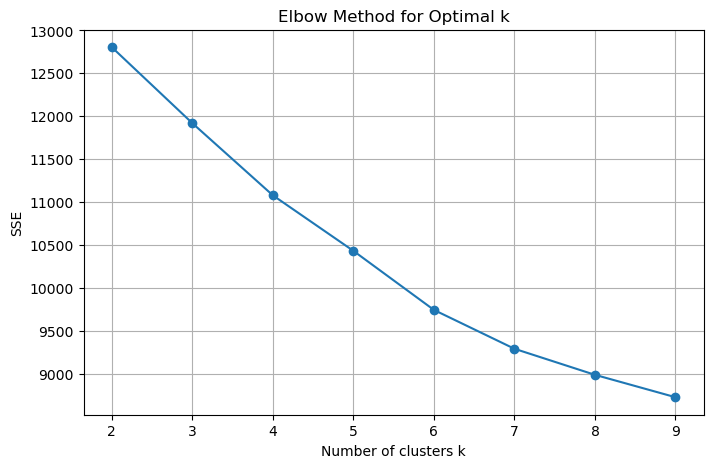

In [40]:
from sklearn.cluster import KMeans

#엘보우 방법으로 최적 k찾기

sse = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_s)
    sse.append(kmeans.inertia_)  # SSE 저장

plt.figure(figsize=(8,5))
plt.plot(K_range, sse, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters k")
plt.ylabel("SSE")
plt.grid(True)
plt.show()

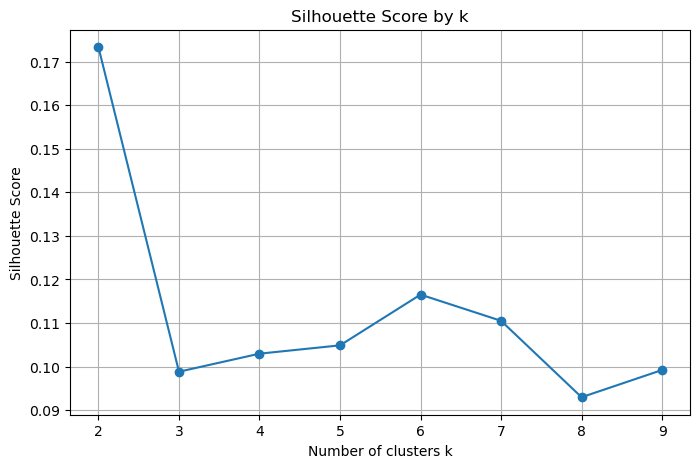

In [41]:
from sklearn.metrics import silhouette_score
#최적의 군집 수를 찾기 위한 두번째 방법: 실루엣 분
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_s)
    sil = silhouette_score(X_s, labels)
    sil_scores.append(sil)

plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score by k")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [42]:
from sklearn.cluster import KMeans

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
df["cluster_kmeans"] = kmeans.fit_predict(X_s)

# 군집별 평균 비교
df.groupby("cluster_kmeans").mean()


C:\Users\Manager\AppData\Local\Temp\ipykernel_19040\3176967894.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["cluster_kmeans"] = kmeans.fit_predict(X_s)
C:\Users\Manager\AppData\Local\Temp\ipykernel_19040\3176967894.py:8: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df.groupby("cluster_kmeans").mean()


,MonthlyIncome,YearsAtCompany,Age,JobSatisfaction,WorkLifeBalance,OverTime,RelationshipSatisfaction,DistanceFromHome,PercentSalaryHike,GrowthPotential2,Attrition
cluster_kmeans,,,,,,,,,,,
0,4350.141509,5.331761,32.179245,2.690252,2.825472,0.261006,2.658805,8.839623,12.984277,-0.046756,0.188679
1,9769.776000,4.244000,47.444000,2.772000,2.644000,0.404000,2.996000,9.108000,14.284000,2.988439,0.128000
2,4619.198370,5.040761,33.932065,2.790761,2.701087,0.239130,2.567935,9.855978,19.831522,0.336742,0.187500
3,12269.953704,18.495370,43.814815,2.685185,2.810185,0.282407,2.787037,9.199074,14.958333,-3.894878,0.074074


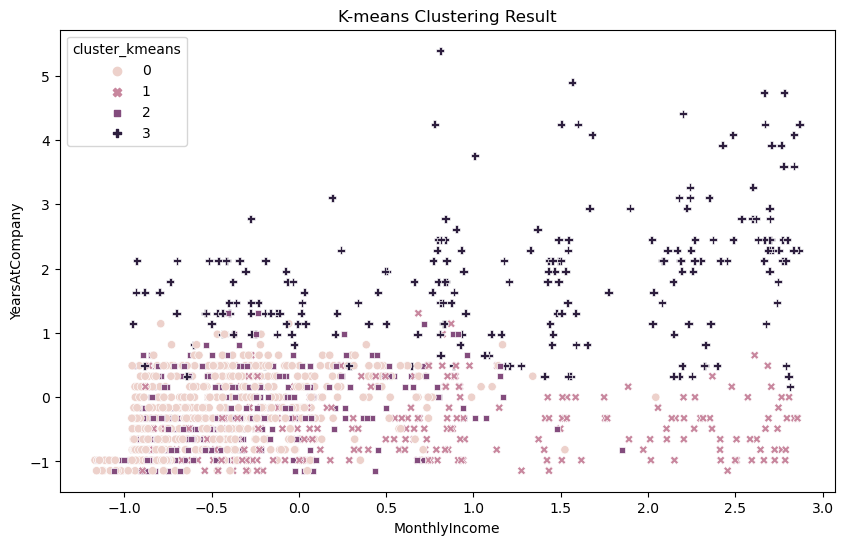

In [43]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=X_s.iloc[:,0], y=X_s.iloc[:,1],
                hue=df["cluster_kmeans"], style=df["cluster_kmeans"])
plt.title("K-means Clustering Result")
plt.show()


## 로지스틱

In [44]:
# 상수항 추가
import statsmodels.api as sm
X_s_const = sm.add_constant(X_s)

# ---------------------------------------------------------
# 2. 기본 로지스틱 회귀 모델
# ---------------------------------------------------------
logit_basic = sm.Logit(y, X_s_const).fit()
print(logit_basic.summary())

Optimization terminated successfully.
         Current function value: 0.374208
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              Attrition   No. Observations:                 1470
Model:                          Logit   Df Residuals:                     1459
Method:                           MLE   Df Model:                           10
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                  0.1528
Time:                        17:13:46   Log-Likelihood:                -550.09
converged:                       True   LL-Null:                       -649.29
Covariance Type:            nonrobust   LLR p-value:                 3.459e-37
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -2.0379      0.096    -21.303      0.000      -2.225

In [47]:
# ---------------------------------------------------------
# 3. 교호작용항 생성
# ---------------------------------------------------------
interaction_pairs = [
    ("MonthlyIncome", "PercentSalaryHike"),
    ("YearsAtCompany", "GrowthPotential2"),
    ("JobSatisfaction", "OverTime"),
    ("DistanceFromHome", "WorkLifeBalance"),
]

X_inter = X_s.copy()

for a, b in interaction_pairs:
    name = f"{a}_x_{b}"
    X_inter[name] = X_s[a] * X_s[b]

# 상수항
X_inter_const = sm.add_constant(X_inter)

# ---------------------------------------------------------
# 4. 교호작용 포함 로지스틱 회귀
# ---------------------------------------------------------
logit_inter = sm.Logit(y, X_inter_const).fit()
print(logit_inter.summary())

# --------------------------------------------
# 3) 오즈비 계산
# --------------------------------------------
params = logit_inter.params
odds_ratios = np.exp(params)
print("\n[ Odds Ratio (오즈비) ]")
print(odds_ratios)


Optimization terminated successfully.
         Current function value: 0.368931
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              Attrition   No. Observations:                 1470
Model:                          Logit   Df Residuals:                     1455
Method:                           MLE   Df Model:                           14
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                  0.1647
Time:                        17:32:28   Log-Likelihood:                -542.33
converged:                       True   LL-Null:                       -649.29
Covariance Type:            nonrobust   LLR p-value:                 7.749e-38
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                 -2.2705      0.121    

## 유의미하지 않은 교호작용항은 2개 뺌

In [48]:
import statsmodels.api as sm
import numpy as np

# --------------------------------------------
# 1) 유의미한 교호작용만 생성
# --------------------------------------------
X_final = X_s.copy()

X_final["MonthlyIncome_x_PercentSalaryHike"] = (
    X_s["MonthlyIncome"] * X_s["PercentSalaryHike"]
)
X_final["YearsAtCompany_x_GrowthPotential2"] = (
    X_s["YearsAtCompany"] * X_s["GrowthPotential2"]
)

# 상수항 추가
X_final_const = sm.add_constant(X_final)

# --------------------------------------------
# 2) 최종 로지스틱 회귀 적합
# --------------------------------------------
logit_final = sm.Logit(y, X_final_const).fit()
print(logit_final.summary())

# --------------------------------------------
# 3) 오즈비 계산
# --------------------------------------------
params = logit_final.params
odds_ratios = np.exp(params)
print("\n[ Odds Ratio (오즈비) ]")
print(odds_ratios)


Optimization terminated successfully.
         Current function value: 0.369003
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              Attrition   No. Observations:                 1470
Model:                          Logit   Df Residuals:                     1457
Method:                           MLE   Df Model:                           12
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                  0.1646
Time:                        17:32:34   Log-Likelihood:                -542.43
converged:                       True   LL-Null:                       -649.29
Covariance Type:            nonrobust   LLR p-value:                 4.766e-39
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                -2.2675      0.120    -18

## 모델 성능 평가 코드


[ Confusion Matrix ]
 [[1211   22]
 [ 195   42]]

Accuracy : 0.8524
Precision: 0.6562
Recall   : 0.1772
F1 Score : 0.2791
ROC-AUC  : 0.7759


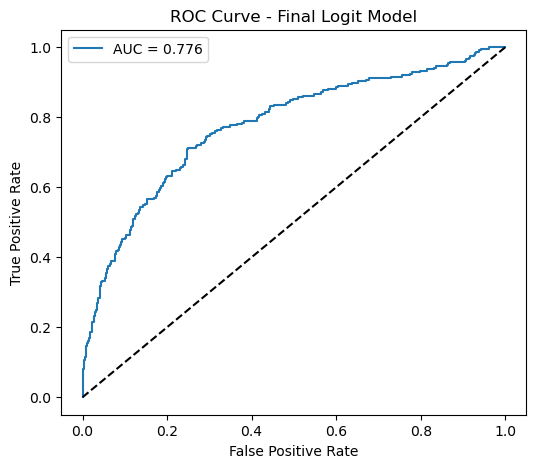

In [49]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# --------------------------------------------
# 1) 예측 확률 및 예측 레이블 생성
# --------------------------------------------
y_pred_prob = logit_final.predict(X_final_const)
y_pred = (y_pred_prob >= 0.5).astype(int)

# --------------------------------------------
# 2) 혼동행렬 & 정확도 등 지표
# --------------------------------------------
cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
auc = roc_auc_score(y, y_pred_prob)

print("\n[ Confusion Matrix ]\n", cm)
print(f"\nAccuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

# --------------------------------------------
# 3) ROC Curve 시각화
# --------------------------------------------
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Logit Model")
plt.legend()
plt.show()
